<a href="https://colab.research.google.com/github/bforsbe/bnot/blob/main/colors_of_noise_and_random_masks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
#!/usr/bin/env python3
"""
generate_colored_noise.py

Generates colored noise images using spectral filtering and an optional
iterative projection to enforce real-space constraints (float clipping or binary).

Produces for each color:
 - image: <prefix>_<color>_image.png
 - log power spectrum: <prefix>_<color>_logps.png
 - radial power spectrum plot: <prefix>_<color>_radial.png

Dependencies: numpy, scipy, matplotlib, Pillow (for saving images)
Install with: pip install numpy scipy matplotlib pillow
"""

import os
import numpy as np
from numpy.fft import fft2, ifft2, fftshift, ifftshift
import matplotlib.pyplot as plt
from scipy import ndimage
from PIL import Image

# ---------- Utilities ----------

def make_frequency_grid(shape):
    """Return (fx, fy, r) frequency grids for given 2D shape, with zero at center (shifted coords)."""
    ny, nx = shape
    ky = np.fft.fftfreq(ny)  # cycles per pixel
    kx = np.fft.fftfreq(nx)
    kxg, kyg = np.meshgrid(kx, ky)
    # convert to radial frequency (cycles per pixel)
    r = np.sqrt(kxg**2 + kyg**2)
    # shift so zero frequency is at center when using fftshift
    return kxg, kyg, fftshift(r)

def target_magnitude(shape, alpha, f0=1e-6, scale=1.0, highpass=None, lowpass=None):
    """
    Construct target magnitude spectrum for power-law 1/f^alpha.
    Power ~ 1 / (f + f0)^alpha
    Magnitude ~ sqrt(Power) ~ 1 / (f + f0)^(alpha/2)
    f0 avoids singularity at zero.
    Optionally apply lowpass/highpass by mask (in cycles/pixel).
    """
    _, _, r = make_frequency_grid(shape)
    # r is in cycles/pixel; to avoid dividing by zero:
    mag = 1.0 / np.power((r + f0), alpha / 2.0)
    # optional high/low pass
    if highpass is not None:
        mag *= (r >= highpass).astype(float)
    if lowpass is not None:
        mag *= (r <= lowpass).astype(float)
    # normalize so typical pixel values are reasonable; caller can scale further
    mag /= np.nanmax(mag)
    return mag * scale

def normalize_image_to_range(img,range):
    img_min = np.min(img)
    img_max = np.max(img)
    return (img - img_min) / (img_max - img_min) * (range[1] - range[0]) + range[0]

def enforce_real_constraints(img, mode='float', clip_range=(0.0, 1.0), threshold=0.5):
    """1
    Enforce real-space constraints on the image.
    mode:
      - 'float' : clip to clip_range
      - 'binary': threshold to 0/1 using threshold; output floats 0.0/1.0
      - 'none'  : do nothing
    """
    if mode == 'float':
        return normalize_image_to_range(img,clip_range)
    elif mode == 'binary':
        img_sorted = np.sort(img.ravel())
        threshold = img_sorted[int(len(img_sorted) * threshold)]
        return (img >= threshold).astype(float)
    elif mode == 'none':
        return img
    else:
        raise ValueError("Unknown mode for real-space constraint: " + str(mode))

def radial_profile(power2d, nbins=100, origin=None):
    """
    Compute radial average of 2D power spectrum (power2d assumed shifted so center is at center).
    Returns (r_centers, radial_mean)
    """
    ny, nx = power2d.shape
    y, x = np.indices((ny, nx))
    if origin is None:
        cx, cy = (nx // 2, ny // 2)
    else:
        cx, cy = origin
    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    r_flat = r.ravel()
    p_flat = power2d.ravel()

    r_max = np.max(r_flat)
    bins = np.linspace(0.0, r_max, nbins + 1)
    inds = np.digitize(r_flat, bins)
    radial_mean = np.zeros(nbins)
    r_centers = 0.5 * (bins[:-1] + bins[1:])
    for i in range(1, nbins + 1):
        mask = inds == i
        if np.any(mask):
            radial_mean[i - 1] = p_flat[mask].mean()
        else:
            radial_mean[i - 1] = np.nan
    return r_centers, radial_mean

# ---------- Core generator (iterative spectral projection) ----------

def generate_blue_noise_mitchell(shape, num_points, candidates=10, seed=None):
    rng = np.random.default_rng(seed)
    points = []

    # First point is random
    first_point = rng.random(2) * shape
    points.append(first_point)

    while len(points) < num_points:
        best_candidate = None
        best_distance = -1

        for _ in range(candidates):
            candidate = rng.random(2) * shape
            distances = np.linalg.norm(np.array(points) - candidate, axis=1)
            min_dist = np.min(distances)

            if min_dist > best_distance:
                best_distance = min_dist
                best_candidate = candidate

        points.append(best_candidate)

    # Rasterize into image
    img = np.zeros(shape, dtype=float)
    for p in points:
        y, x = int(p[1]), int(p[0])
        img[y % shape[0], x % shape[1]] = 1.0

    return img

def generate_colored_noise(shape=(512, 512),
                           alpha=0.0,
                           rng=None,
                           scale=1.0,
                           iterations=0,
                           real_constraint='float',
                           clip_range=(0.0, 1.0),
                           binary_threshold=0.5,
                           f0=1e-6):
    """
    Generate a colored noise image of given power-law slope alpha.
    If iterations > 0, perform iterative projection:
      1) start with white noise image (real-space)
      2) FFT -> replace magnitude with target magnitude while keeping phases
      3) inverse FFT -> enforce real-space constraint (clip/binary)
      4) repeat
    Returns the final real-space image and final complex FFT (shifted).
    """
    if rng is None:
        rng = np.random.default_rng()

    ny, nx = shape
    # initial real-space white noise (normal)
    img = rng.standard_normal(size=shape)

    # target magnitude (shifted)
    target_mag = target_magnitude(shape, alpha=alpha, f0=f0, scale=scale)

    # Note: target_mag is in fftshifted coordinates; we'll handle shifts consistently.
    if alpha==-1.0 and real_constraint=='binary':
        img = generate_blue_noise_mitchell(img.shape,
                                           int((1-binary_threshold)*len(img.ravel())),
                                           candidates=20,
                                           seed=rng
                                           )
    else:
      for it in range(max(1, iterations)):
          # FFT of current img
          F = fft2(img)
          Fshift = fftshift(F)  # center low freqs
          phases = np.angle(Fshift)
          # set new spectrum = target magnitude * exp(i*phase)
          newFshift = target_mag * np.exp(1j * phases)
          # unshift and inverse FFT
          newF = ifftshift(newFshift)
          img = np.real(ifft2(newF))
          # enforce real-space constraints
          img = enforce_real_constraints(img, mode=real_constraint,
                                        clip_range=clip_range, threshold=binary_threshold)
          # if iterations == 0 we still want to do at least once spectral shaping:
          if iterations == 0:
              break

    # compute final FFT (shifted) for debug/export
    F_final = fftshift(fft2(img))
    return img, F_final, target_mag

# ---------- Plot & save helpers ----------

def save_image_float(img, path, vmin=None, vmax=None):
    """Save float image as 8-bit PNG after scaling/clipping to vmin/vmax (if provided)."""
    arr = img.copy()
    if vmin is None:
        vmin = arr.min()
    if vmax is None:
        vmax = arr.max()
    # avoid divide by zero
    if vmax - vmin == 0:
        scaled = np.zeros_like(arr, dtype=np.uint8)
    else:
        scaled = 255 - 255.0 * (arr - vmin) / (vmax - vmin)
        scaled = np.clip(scaled, 0, 255).astype(np.uint8)
    Image.fromarray(scaled).save(path)

def plot_and_save_log_power(Fshift, outpath, clim=None, cmap='viridis'):
    """Plot log10 power spectrum (shifted) and save figure."""
    ps = np.abs(Fshift)**2
    logps = np.log10(ps + 1e-12)  # avoid log(0)
    plt.figure(figsize=(4,4))
    plt.imshow(logps, origin='lower', cmap=cmap)
    plt.axis('off')
    if clim is not None:
        plt.clim(clim)
    plt.tight_layout(pad=0)
    plt.savefig(outpath, dpi=150, bbox_inches='tight', pad_inches=0)
    plt.close()

def radial_log_profile(Fshift, nbins=50, fmin=None, fmax=None, fit=True, alpha_guess=None):
    """
    Compute radial power spectrum in log-spaced frequency bins and optionally fit a line.
    Fshift: complex FFT with zero-frequency at center (fftshifted)
    Returns: dict with keys: f_centers, power_mean, power_std, slope, intercept, r2
    """
    ny, nx = Fshift.shape
    # frequency coordinates in cycles per pixel (unshifted coords)
    ky = np.fft.fftfreq(ny)
    kx = np.fft.fftfreq(nx)
    kxg, kyg = np.meshgrid(kx, ky)
    r = np.sqrt(kxg**2 + kyg**2)  # cycles/pixel, unshifted layout

    # shift r to match Fshift indexing (Fshift has center at [ny//2, nx//2])
    r = np.fft.fftshift(r)

    power2d = np.abs(Fshift)**2

    # choose fmin/fmax
    r_flat = r.ravel()
    p_flat = power2d.ravel()
    # remove zeros and tiny values for log
    mask_finite = np.isfinite(r_flat) & np.isfinite(p_flat)
    r_flat = r_flat[mask_finite]
    p_flat = p_flat[mask_finite]

    # set sensible defaults: ignore DC (f=0)
    eps = 1e-12
    mask_positive = r_flat > eps
    r_flat = r_flat[mask_positive]
    p_flat = p_flat[mask_positive]

    if fmin is None:
        fmin = r_flat.min()
    if fmax is None:
        fmax = r_flat.max()

    # log-spaced bins between fmin and fmax
    bins = np.logspace(np.log10(fmin), np.log10(fmax), nbins + 1)
    inds = np.digitize(r_flat, bins)

    f_centers = 0.5 * (bins[:-1] + bins[1:])
    p_mean = np.full(nbins, np.nan)
    p_std = np.full(nbins, np.nan)
    counts = np.zeros(nbins, dtype=int)

    for i in range(1, nbins + 1):
        sel = inds == i
        counts[i-1] = sel.sum()
        if counts[i-1] > 0:
            vals = p_flat[sel]
            p_mean[i-1] = vals.mean()
            p_std[i-1] = vals.std(ddof=0) / np.sqrt(counts[i-1])  # SEM

    # keep bins with data
    valid = counts > 0
    f_centers = f_centers[valid]
    p_mean = p_mean[valid]
    p_std = p_std[valid]
    counts = counts[valid]

    result = {
        'f': f_centers,
        'power': p_mean,
        'power_sem': p_std,
        'counts': counts,
        'slope': None,
        'intercept': None,
        'r2': None
    }

    if fit and len(f_centers) >= 2:
        # linear fit in log-log: log10(P) = m * log10(f) + b  -> slope = m
        lx = np.log10(f_centers)
        ly = np.log10(p_mean)
        # optionally exclude extreme low/high bins manually if needed
        # perform weighted linear regression with weights = sqrt(counts)
        w = np.sqrt(counts)
        W = np.diag(w)
        # use numpy.polyfit with weights
        m, b = np.polyfit(lx, ly, 1, w=w)
        # compute r2
        ypred = m * lx + b
        ss_res = np.sum(w * (ly - ypred)**2)
        ss_tot = np.sum(w * (ly - np.average(ly, weights=w))**2)
        r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

        result.update({'slope': m, 'intercept': b, 'r2': r2})

    return result

def plot_and_save_radial(power2d, outpath, nbins=200, xlabel='radius (pixels)', title=None):
    #rcenters, radial = radial_profile(power2d, nbins=nbins)
    rlp = radial_log_profile(power2d, nbins=nbins)
    rcenters = rlp['f']
    radial = rlp['power']

    plt.figure(figsize=(4.5,3))
    plt.plot(rcenters, radial, marker='.', markersize=3, linestyle='-')
    plt.xlabel(xlabel)
    plt.ylabel('Mean power')
    plt.loglog()
    plt.grid(True, linestyle=':', alpha=0.4)
    if title:
        plt.title(title)
    plt.grid(True, linestyle=':', alpha=0.4)
    plt.tight_layout()
    plt.savefig(outpath, dpi=150)
    plt.close()
    return rlp



# ---------- High-level driver ----------

def generate_and_save_all(output_dir='output_noise',
                          prefix='noise',
                          shape=(512,512),
                          colors=None,
                          iterations=100,
                          real_constraint='float',
                          clip_range=(0.0,1.0),
                          binary_threshold=0.5,
                          rng_seed=1234,
                          scale=1.0,
                          mask=None):
    """
    colors: dict mapping name->alpha (power law exponent for power ~ 1/f^alpha).
      Example: {'white': 0.0, 'pink': 1.0, 'brown':2.0, 'blue': -1.0, 'violet': -2.0}
    iterations: number of spectral-projection iterations (0 does one-pass spectral shaping)
    real_constraint: 'none', 'float', or 'binary'
    """
    output_dir = f"{real_constraint}_{output_dir}"
    os.makedirs(output_dir, exist_ok=True)
    rng = np.random.default_rng(rng_seed)
    if colors is None:
        colors = {'white': 0.0, 'pink': 1.0, 'brown': 2.0, 'blue': -1.}#0, 'violet': -2.0}

    # --- new: storage for all radial profiles ---
    all_radials = {}
    all_images = {}
    all_Fshift = {}

    for name, alpha in colors.items():
      if real_constraint == 'float':
        alpha/=2
      print(f"Generating {name} noise (alpha={alpha}) ...")
      img, Fshift, target_mag = generate_colored_noise(
          shape=shape,
          alpha=alpha,
          rng=rng,
          scale=scale,
          iterations=iterations,
          real_constraint=real_constraint,
          clip_range=clip_range,
          binary_threshold=binary_threshold,
          f0=1e-6
      )

      # file names
      base = f"{prefix}_{name}"
      img_path = os.path.join(output_dir, base + "_image.png")
      logps_path = os.path.join(output_dir, base + "_logps.png")
      radial_path = os.path.join(output_dir, base + "_radial.png")

      # Save image - if binary, save 0/255; else scale to 0..1
      if real_constraint == 'binary':
          save_image_float(img, img_path, vmin=0.0, vmax=1.0)
      else:
          # scale based on a symmetric clip around mean for nicer contrast
          mean = np.mean(img)
          std = np.std(img)
          vmin = mean - 3*std
          vmax = mean + 3*std
          save_image_float(img, img_path, vmin=vmin, vmax=vmax)

      # Save log power spectrum
      plot_and_save_log_power(Fshift, logps_path)

      # Save radial power spectrum (use shifted power)
      ps = np.abs(Fshift)**2
      res = plot_and_save_radial(ps, radial_path, nbins=200, title=f"{name} (alpha={alpha})")
      all_radials[name] = res
      all_images[name] = img

      print(f"Saved: {img_path}, {logps_path}, {radial_path}")

    # --- after loop: combined log–log plot ---
    # Match the order of your colors dict
    cycle_colors = ['black', 'magenta', 'saddlebrown', 'dodgerblue', 'mediumvioletred']
    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=cycle_colors)

    plt.figure(figsize=(6,5))
    for name, res in all_radials.items():
        f = res['f']
        p = res['power']
        plt.plot(f, p, label=f"{name} (slope={res['slope']:.2f})")
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Spatial frequency (cycles/pixel)')
    plt.ylabel('Power')
    plt.legend()
    plt.grid(True, which='both', ls=':')
    plt.tight_layout()
    combined_path = os.path.join(output_dir, f"{prefix}_radial_comparison.png")
    plt.savefig(combined_path, dpi=150)
    plt.close()
    print(f"Saved combined radial comparison: {combined_path}")

    if mask is not None:
        plt.figure(figsize=(6,5))
        for name, img in all_images.items():
            img_masked = img * mask
            img_path = os.path.join(output_dir, f"{prefix}_{name}_image_masked.png")
            save_image_float(img_masked, img_path, vmin=0.0, vmax=1.0)
            Fshift_masked = fftshift(fft2(img_masked))
            rlp = radial_log_profile(Fshift_masked, nbins=100)
            rcenters = rlp['f']
            radial = rlp['power']
            plt.plot(rcenters, radial, label=f"{name}")
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Spatial frequency (cycles/pixel)')
        plt.ylabel('Power')
        plt.legend()
        plt.grid(True, which='both', ls=':')
        plt.tight_layout()
        plt.show()









In [222]:
# ---------- Example CLI-like usage ----------

if __name__ == "__main__":
    # minimal example run (tweak parameters here)
    output_dir='noise_examples'
    real_constraint='float'
    generate_and_save_all(
        output_dir=output_dir,
        prefix='noise',
        shape=(256,256),
        colors={'white':0.0, 'pink':3.0, 'brown':6.0, 'blue':-3.0},#, 'violet':-2.0},
        iterations=1,                # use iterative projection to better match spectrum while enforcing constraints
        real_constraint=real_constraint,      # 'none', 'float', or 'binary'
        clip_range=(0.0,1.0),
        binary_threshold=0.9,
        rng_seed=42,
        scale=1.0
    )
    print(f"Done. Check the folder {real_constraint}_{output_dir}.")

Generating white noise (alpha=0.0) ...
Saved: float_noise_examples/noise_white_image.png, float_noise_examples/noise_white_logps.png, float_noise_examples/noise_white_radial.png
Generating pink noise (alpha=1.5) ...
Saved: float_noise_examples/noise_pink_image.png, float_noise_examples/noise_pink_logps.png, float_noise_examples/noise_pink_radial.png
Generating brown noise (alpha=3.0) ...
Saved: float_noise_examples/noise_brown_image.png, float_noise_examples/noise_brown_logps.png, float_noise_examples/noise_brown_radial.png
Generating blue noise (alpha=-1.5) ...
Saved: float_noise_examples/noise_blue_image.png, float_noise_examples/noise_blue_logps.png, float_noise_examples/noise_blue_radial.png
Saved combined radial comparison: float_noise_examples/noise_radial_comparison.png
Done. Check the folder float_noise_examples.


In [199]:
!zip -r binary_noise_examples_masked.zip binary_noise_examples
from google.colab import files
files.download('binary_noise_examples_masked.zip')

  adding: binary_noise_examples/ (stored 0%)
  adding: binary_noise_examples/noise_pink_radial.png (deflated 10%)
  adding: binary_noise_examples/noise_brown_radial.png (deflated 10%)
  adding: binary_noise_examples/noise_brown_logps.png (deflated 0%)
  adding: binary_noise_examples/noise_blue_radial.png (deflated 8%)
  adding: binary_noise_examples/noise_brown_image_masked.png (deflated 5%)
  adding: binary_noise_examples/noise_pink_image.png (stored 0%)
  adding: binary_noise_examples/noise_blue_logps.png (deflated 0%)
  adding: binary_noise_examples/noise_pink_logps.png (deflated 0%)
  adding: binary_noise_examples/noise_brown_image.png (stored 0%)
  adding: binary_noise_examples/noise_white_image_masked.png (deflated 4%)
  adding: binary_noise_examples/noise_blue_image_masked.png (deflated 4%)
  adding: binary_noise_examples/noise_white_logps.png (deflated 0%)
  adding: binary_noise_examples/noise_pink_image_masked.png (deflated 4%)
  adding: binary_noise_examples/noise_radial_comp

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
!zip -r float_noise_examples.zip float_noise_examples
from google.colab import files
files.download('float_noise_examples.zip')

  adding: float_noise_examples/ (stored 0%)
  adding: float_noise_examples/noise_white_image.png (deflated 0%)
  adding: float_noise_examples/noise_pink_radial.png (deflated 12%)
  adding: float_noise_examples/noise_radial_comparison.png (deflated 11%)
  adding: float_noise_examples/noise_violet_image.png (deflated 0%)
  adding: float_noise_examples/noise_white_radial.png (deflated 14%)
  adding: float_noise_examples/noise_blue_logps.png (deflated 0%)
  adding: float_noise_examples/noise_blue_radial.png (deflated 12%)
  adding: float_noise_examples/noise_brown_logps.png (deflated 0%)
  adding: float_noise_examples/noise_pink_logps.png (stored 0%)
  adding: float_noise_examples/noise_pink_image.png (deflated 0%)
  adding: float_noise_examples/noise_brown_radial.png (deflated 13%)
  adding: float_noise_examples/noise_violet_radial.png (deflated 12%)
  adding: float_noise_examples/noise_violet_logps.png (stored 0%)
  adding: float_noise_examples/noise_brown_image.png (deflated 0%)
  addin

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [209]:
import numpy as np
from scipy.ndimage import binary_erosion, center_of_mass, label

def largest_object(binary_img, structure=None):
    """Return binary mask of the largest connected component."""
    if structure is None:
        structure = np.ones((3, 3), dtype=bool)
    labeled, num = label(binary_img, structure=structure)
    if num == 0:
        return np.zeros_like(binary_img, dtype=bool)
    sizes = np.bincount(labeled.ravel())
    largest_label = sizes[1:].argmax() + 1
    return (labeled == largest_label)

def crop_centered_on_cog(img, center_y, center_x, h, w):
    """Crop h×w window from img centered at (center_y, center_x) with periodic wrapping."""
    out = np.zeros((h, w), dtype=img.dtype)
    H, W = img.shape
    y_indices = (np.arange(h) + int(center_y - h // 2)) % H
    x_indices = (np.arange(w) + int(center_x - w // 2)) % W
    out = img[np.ix_(y_indices, x_indices)]
    return out

def periodic_erosion_centered(binary_img, n, structure=None, only_largest=True):
    """
    Periodically extend, find largest object, crop h×w window centered on its COG,
    then erode until edges are n pixels clear.
    """
    if structure is None:
        structure = np.ones((3, 3), dtype=bool)

    h, w = binary_img.shape

    # Step 1: periodic 3×3 tiling
    tiled = np.tile(binary_img, (3, 3))

    # Step 2: find largest object in tiled space
    largest = largest_object(tiled, structure=structure)

    # Step 3: find its COG
    cy, cx = center_of_mass(largest)

    # Step 4: crop h×w window centered on COG with periodic wrap
    if only_largest:
        tiled = largest

    img = crop_centered_on_cog(tiled, cy, cx, h, w)

    # Step 5: iterative periodic erosion
    iterations = 0

    # Check n-pixel-clear condition
    top_clear = np.all(img[:n, :] == 0)
    bottom_clear = np.all(img[-n:, :] == 0)
    left_clear = np.all(img[:, :n] == 0)
    right_clear = np.all(img[:, -n:] == 0)

    if top_clear and bottom_clear and left_clear and right_clear:
        return img.astype(binary_img.dtype), iterations
    else:
        return None, None


In [181]:
def random_mask(shape,alpha=5,coverage=0.5,rng_seed=None):
    if rng_seed is None:
        import time
        seed = int(time.time() * 1000)
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng(rng_seed)

    base, Fshift, target_mag = generate_colored_noise(
          shape=shape,
          alpha=alpha,
          rng=rng,
          scale=1.0,
          iterations=10,
          real_constraint='binary',
          clip_range=None,
          binary_threshold=coverage,
          f0=1e-6
      )
    return 1-base

In [197]:
import numpy as np
import time
import matplotlib.pyplot as plt

def generate_random_shape_mask(
    size=(256, 256),
    alpha=3,
    coverage=0.8,
    n_edge=10,
    rng_seed=None,
    max_attempts=100,
    random_mask_fn=None,
    plot=False
):
    """
    Generate a random shape mask with periodic centering and n_edge-clear borders.

    Parameters
    ----------
    size : tuple
        (height, width) of mask.
    alpha : float
        Shape generation parameter (passed to random_mask_fn).
    coverage : float
        Coverage fraction for mask generation.
    n_edge : int
        Number of border pixels that must be zero after centering.
    rng_seed : int or None
        Random seed. If provided and fails, raises ValueError.
    max_attempts : int
        Max tries if rng_seed is None.
    random_mask_fn : callable
        Function to generate base random mask. Must accept:
            shape=(h, w), alpha=alpha, coverage=coverage, rng_seed=seed
        and return a binary mask.
    plot : bool
        If True, display the final mask.

    Returns
    -------
    mask : np.ndarray
        Binary mask (uint8) with edges clear.
    seed : int
        Seed that produced this mask.
    """
    if random_mask_fn is None:
        raise ValueError("You must provide a random_mask_fn implementation.")

    fixed_seed = rng_seed is not None
    h, w = size

    for attempt in range(max_attempts if not fixed_seed else 1):
        seed = rng_seed if fixed_seed else int(time.time() * 1000)

        # Generate base mask
        mask = 1 - random_mask_fn(size, alpha=alpha, coverage=coverage, rng_seed=seed)

        # Periodic centering
        mask, _ = periodic_erosion_centered(mask, n_edge)

        if mask is not None:
            if plot:
                plt.imshow(mask, cmap='gray')
                plt.title(f"Seed: {seed}")
                plt.show()
            return mask, seed

        if fixed_seed:
            raise ValueError(f"Provided seed {rng_seed} does not produce valid mask.")

    raise RuntimeError(f"Failed to generate valid mask after {max_attempts} attempts.")


tried 13 times
1755095822397
0


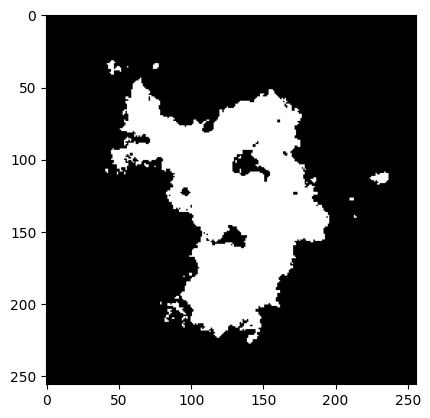

In [196]:
SZ=256

import time

mask = 1-random_mask((SZ,SZ),alpha=4,coverage=0.8, rng_seed=1755093417093)
mask = 1-random_mask((SZ,SZ),alpha=3.5,coverage=0.8,rng_seed=1755093905763)

#mask = mask > 1

alpha=3
coverage=0.8
n_edge=10

# Good seeds at alpha 3 coverage 0.8 n_edge 10
# 1755095661967
# 1755095707707



mask = 1-random_mask((SZ,SZ),alpha=3.5,coverage=0.8,rng_seed=1755093984038)
mask = 1-random_mask((SZ,SZ),alpha=alpha,coverage=coverage)
mask,iterations = periodic_erosion_centered(mask, n_edge)
#plt.imshow(mask,cmap='gray')
#plt.show()
#print(np.sum(mask)/np.float32(SZ*SZ))

tries=0
if mask is None:
    while mask is None and tries<100:
        seed = int(time.time() * 1000)
        mask = 1-random_mask((SZ,SZ),alpha=alpha,coverage=coverage,rng_seed=seed)
        mask,iterations = periodic_erosion_centered(mask, n_edge)
        tries+=1
    print(f'tried {tries} times')
    print(seed)

print (iterations)

if mask is not None:
    plt.imshow(mask,cmap='gray')
    plt.show()

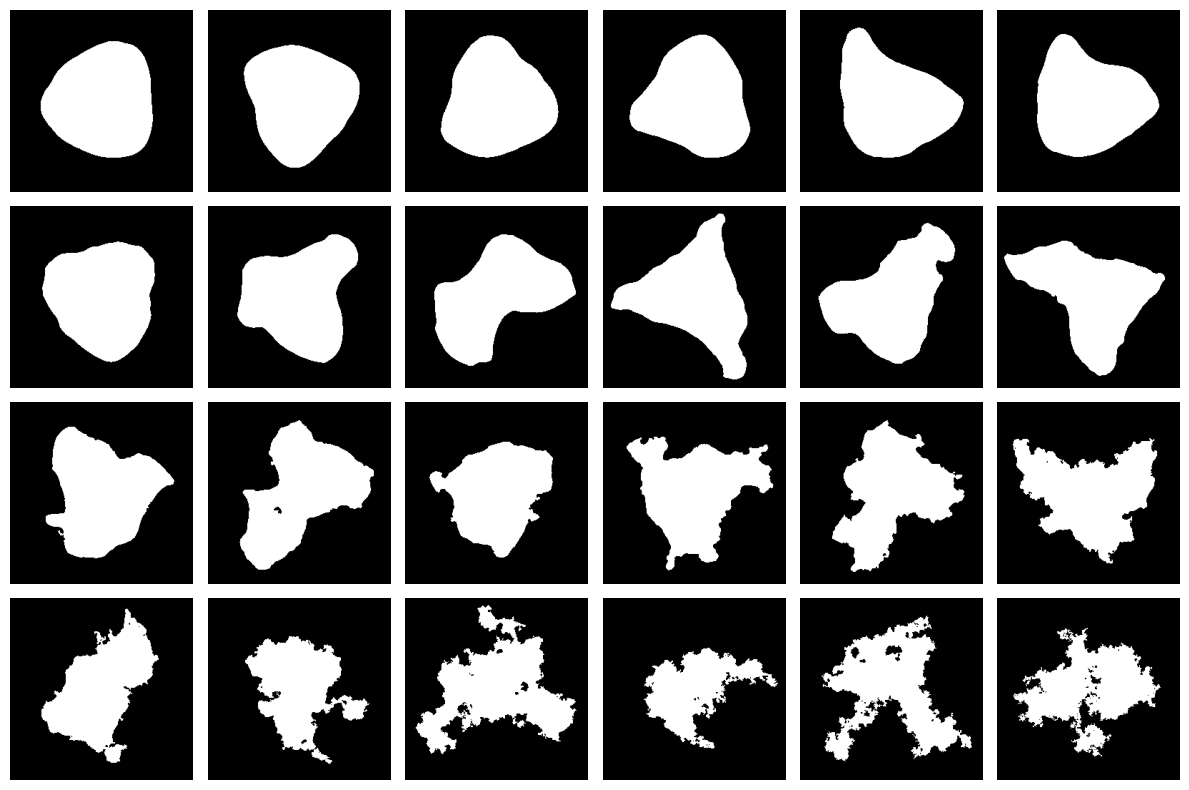

In [217]:
import matplotlib.pyplot as plt

# Parameters
N, M = 4, 6        # Grid: N rows x M columns
img_size = (256,256) # Size of each random image

# Create figure
fig, axes = plt.subplots(N, M, figsize=(M*2, N*2))

inc = 0.0
for i in range(N):
    for j in range(M):
        # Generate a random image/mask
        img, seed = generate_random_shape_mask(
        size=(256,256),
        alpha=5-inc,
        coverage=0.7,
        n_edge=10,
        random_mask_fn=random_mask,
        plot=False
        )

        inc += 0.1

        # Plot
        ax = axes[i, j]
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        #ax.set_title(f"S:{seed}")


plt.tight_layout()
plt.show()


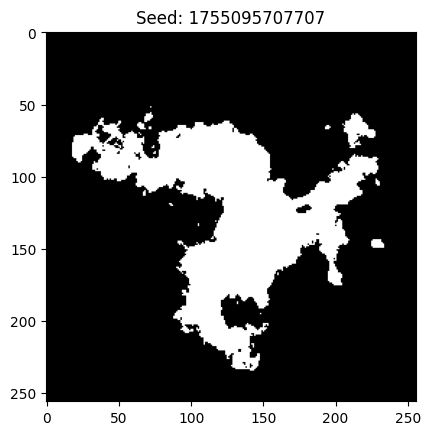

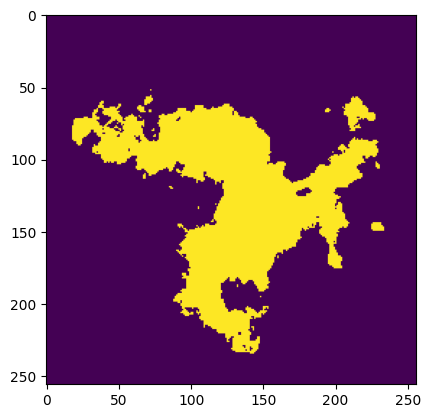

Generating white noise (alpha=0.0) ...
Saved: binary_noise_examples/noise_white_image.png, binary_noise_examples/noise_white_logps.png, binary_noise_examples/noise_white_radial.png
Generating pink noise (alpha=1.0) ...
Saved: binary_noise_examples/noise_pink_image.png, binary_noise_examples/noise_pink_logps.png, binary_noise_examples/noise_pink_radial.png
Generating brown noise (alpha=2.0) ...
Saved: binary_noise_examples/noise_brown_image.png, binary_noise_examples/noise_brown_logps.png, binary_noise_examples/noise_brown_radial.png
Generating blue noise (alpha=-1.0) ...
Saved: binary_noise_examples/noise_blue_image.png, binary_noise_examples/noise_blue_logps.png, binary_noise_examples/noise_blue_radial.png
Saved combined radial comparison: binary_noise_examples/noise_radial_comparison.png


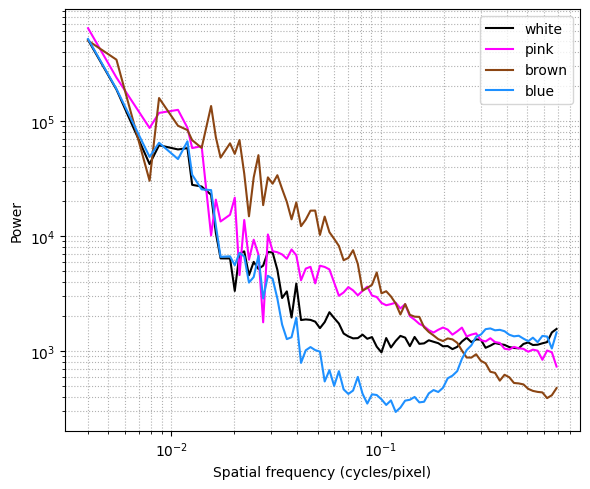

Done. Check the folder binary_noise_examples.


In [198]:
seed = 1755086688796
seed = 1755087403748

SZ=256

#mask = random_mask((SZ,SZ),alpha=4,coverage=0.2,rng_seed=seed)
#mask = 1-random_mask((SZ,SZ),alpha=3.5,coverage=0.8,rng_seed=1755093984038)
#mask,iterations = periodic_erosion_centered(mask, 10)

mask, seed = generate_random_shape_mask(
    size=(256,256),
    alpha=3,
    coverage=0.8,
    n_edge=10,
    rng_seed=1755095707707,
    random_mask_fn=random_mask,
    plot=True
)

plt.imshow(mask)
plt.show()

if __name__ == "__main__":
    # minimal example run (tweak parameters here)
    output_dir='noise_examples'
    real_constraint='binary'
    generate_and_save_all(
        output_dir=output_dir,
        prefix='noise',
        shape=mask.shape,
        colors={'white':0.0, 'pink':1.0, 'brown':2.0, 'blue':-1.0},#, 'violet':-2.0},
        iterations=1,                # use iterative projection to better match spectrum while enforcing constraints
        real_constraint=real_constraint,      # 'none', 'float', or 'binary'
        clip_range=(0.0,1.0),
        binary_threshold=0.9,
        rng_seed=42,
        scale=1.0,
        mask=mask
    )
    print(f"Done. Check the folder {real_constraint}_{output_dir}.")
